## **Silhouette values and Elbow charts:**

### Import Packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score

from scipy.spatial.distance import pdist, squareform

### Create Cluster Data

In [2]:
X, y = make_blobs(n_samples=150, n_features=2, centers=3, 
           cluster_std=2.5, shuffle=True, random_state=42)

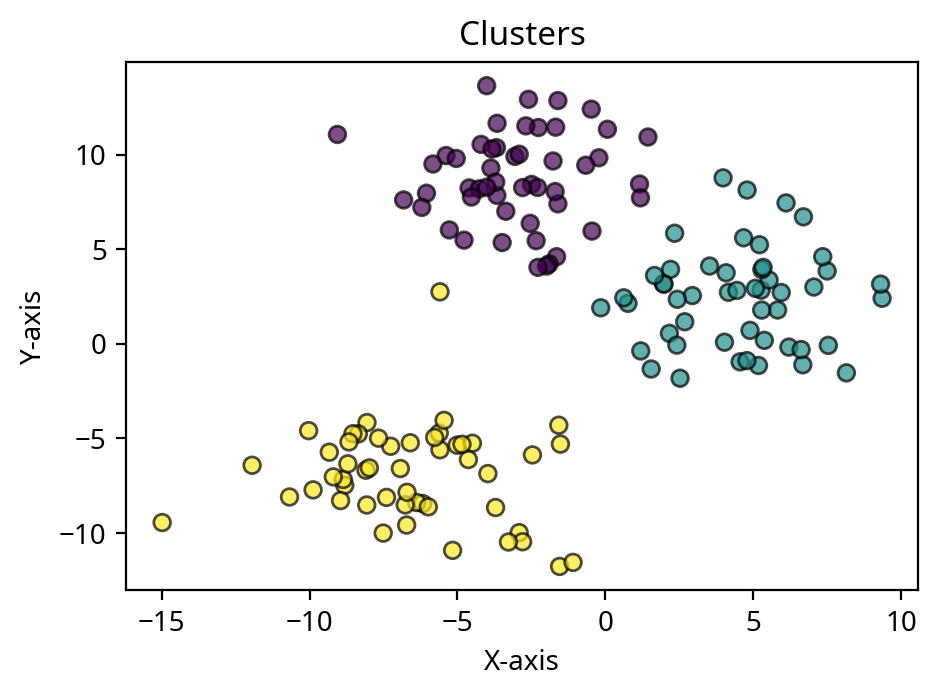

In [3]:
plt.scatter(X[:, 0], X[:,1], c=y, edgecolors='k', alpha=0.7)
plt.title('Clusters')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.tight_layout()
plt.show()

### Fit the KMeans model

In [107]:
kmeans = KMeans(n_clusters=3, init='k-means++', n_init=10,
                max_iter=500, random_state=42)

In [108]:
labels = kmeans.fit_predict(X)

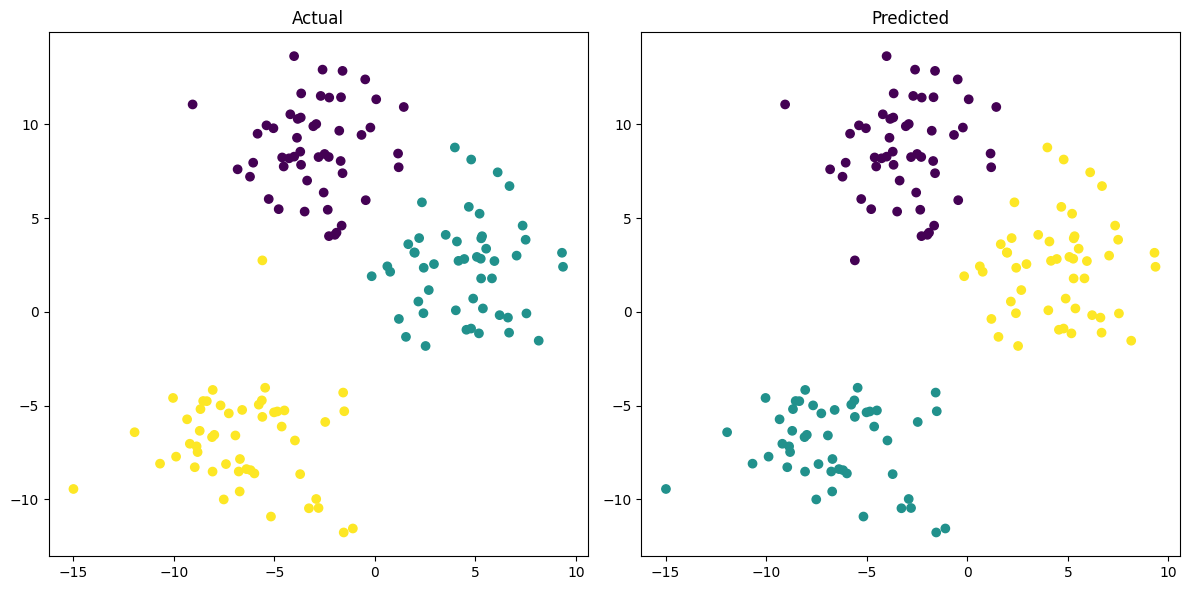

In [109]:
fig, axes = plt.subplots(1,2, figsize=(12,6))

axes[0].scatter(X[:,0], X[:, 1], c=y)
axes[0].set_title('Actual')

axes[1].scatter(X[:,0], X[:, 1], c=labels)
axes[1].set_title('Predicted')

plt.tight_layout()
plt.show()

In [110]:
# Calculate the silhouette values
silhouette_vals = silhouette_samples(X, labels, metric='euclidean')

print(f'Examples - 5 silhouette value: {silhouette_vals[:5]}')
print(f'Mean of silhouette values: {silhouette_vals.mean():.3f}')
print(f'Max of silhouette values: {silhouette_vals.max():.3f}')
print(f'Min of silhouette values: {silhouette_vals.min():.3f}')

Examples - 5 silhouette value: [0.61384809 0.70531344 0.77537859 0.60005809 0.73194483]
Mean of silhouette values: 0.614
Max of silhouette values: 0.791
Min of silhouette values: 0.072


### Plot the silhouette for each cluster

In [111]:
from matplotlib import cm

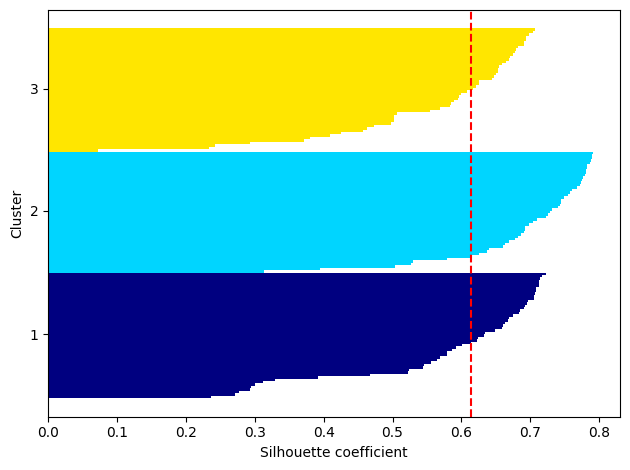

In [112]:
cluster_labels = np.unique(labels)
n_clusters = len(cluster_labels)

y_ax_lower, y_ax_upper = 0, 0
yticks = []

for i, c in enumerate(cluster_labels):
    # grab silhouette values for each cluster
    c_silhouette_vals = silhouette_vals[labels == c]
    c_silhouette_vals.sort()

    # plot y and x axes
    y_ax_upper += len(c_silhouette_vals) # total numbers of each class
    color = cm.jet(float(i) / n_clusters) #  cm.jet() input values from 0-1 and generate color map

    plt.barh(range(y_ax_lower, y_ax_upper),
             c_silhouette_vals,
             height=1.0, # bar thickness to 1.0, bar touch each other without gaps
             edgecolor='none',
             color = color)
    yticks.append((y_ax_lower + y_ax_upper) / 2.0)
    y_ax_lower += len(c_silhouette_vals)

# plot average value across clusters
silhouette_avgs = np.mean(silhouette_vals)
plt.axvline(silhouette_avgs, color='red', linestyle='--')

plt.yticks(yticks, cluster_labels + 1)
plt.ylabel('Cluster')
plt.xlabel('Silhouette coefficient')
plt.tight_layout()
plt.show()


In [113]:
X[:5]

array([[-2.59876272, 12.92589527],
       [-4.60724143,  8.24125519],
       [-6.17714752, -8.43685839],
       [ 9.35534359,  2.40961422],
       [-5.59203902, -5.59564472]])

#### **Elbow - Find Optimal number of clusters (k):**

In [116]:
# initialize within-cluster SSE list
wc_SEE = []

# fit KMeans models with different numbers of clusters
for i in range(1,11):
    km = KMeans(n_clusters=i,
                init='k-means++',
                n_init=10,
                max_iter=300,
                tol=1e-04,
                random_state=0)
    km.fit(X)
    wc_SEE.append(km.inertia_)

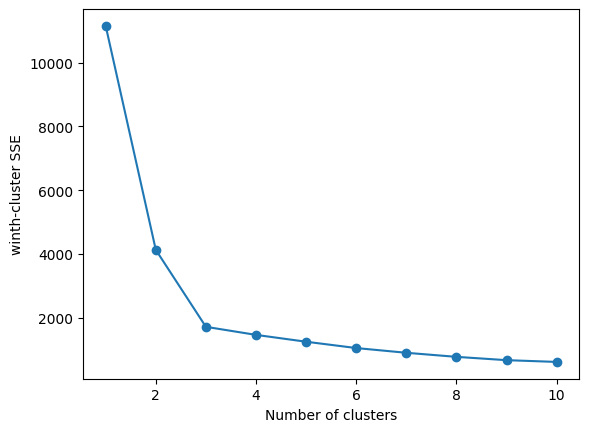

In [118]:
plt.plot(range(1,11), wc_SEE, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('winth-cluster SSE')
plt.show()